# vlm classifer for 5cls 

* /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm_mbhseg_5cls_dataset

* prompt
    * Reader #2라고 가정
    * full overlay image + cropped image 각각 설명
    * ICH 종류 설명
    * 판단: 병변이 맞는지 / 클래스가 뭔지를 출력

* 결과
    * full_predictions_non_thinking_5cls.json
    * GT와 vlm 판단 비교
    * pred와 vlm 판단 비교
    * class 별 정확도
    * vlm confusion matrix

* Qwen3.5-27B

In [23]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from enum import Enum
from pydantic import BaseModel, ValidationError
from openai import OpenAI
import base64
from io import BytesIO

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")

In [24]:
# windowing
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

# 이미지를 base64로 변환
def pil_to_base64_url(img: Image.Image) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"

In [25]:
def to_rgb_pil(img):
    """np.ndarray / PIL / 경로 어떤 형태로 들어와도 RGB PIL로 통일"""
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        if img.shape[-1] == 4:
            img = img[..., :3]
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
        return Image.fromarray(img).convert("RGB")
    if isinstance(img, (str, bytes)):
        return Image.open(img).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(img)}")


def extract_first_json(text: str) -> str:
    """모델 출력에서 첫 번째 완결된 JSON 객체만 잘라냄 (중첩 괄호 대응)"""
    start = text.find("{")
    if start == -1:
        raise ValueError(f"No JSON found: {text}")
    depth, end = 0, None
    for i, ch in enumerate(text[start:], start=start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i + 1
                break
    if end is None:
        raise ValueError(f"Unterminated JSON: {text}")
    return text[start:end]


def load_lps_array(path):
    """DICOM 표준 axial view로 보이도록 LPS 재정렬 후 (z, y, x) 배열 반환."""
    img_sitk = sitk.ReadImage(str(path))
    img_lps = sitk.DICOMOrient(img_sitk, "LPS")
    return sitk.GetArrayFromImage(img_lps)

In [26]:
class_names = {
    0: 'NONE',
    1: 'EDH',
    2: 'IPH',
    3: 'IVH',
    4: 'SAH',
    5: 'SDH',
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

In [27]:
from openai import OpenAI
import base64
from io import BytesIO

client = OpenAI(base_url="http://localhost:8891/v1", api_key="EMPTY")
MODEL_NAME = "Qwen/Qwen3.5-27B"

GEN_CONFIGS = {
    "non_thinking": dict(
        temperature=0.0, max_tokens=1024, seed=0,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}},
    ),
}

In [28]:
class ICHType(str, Enum):
    edh = "EDH"
    sdh = "SDH"
    sah = "SAH"
    ivh = "IVH"
    iph = "IPH"
    none = "NONE"

class ICHResult(BaseModel):
    is_lesion: bool
    lesion_type: ICHType

In [29]:
def build_prompt():
    return """
    You are Reader #2, providing an independent second read of a candidate brain hemorrhage finding
    from a non-contrast head CT, originally flagged by a segmentation model (Reader #1). You do not
    see Reader #1's classification — judge independently from the images alone.

    You are given two images of the flagged region.
    Image 1: the full axial slice, with the flagged region highlighted, showing its location relative
    to the skull/ventricles/brain surface.
    Image 2: a zoomed-in crop of the region, showing its shape and density pattern in detail.

    Reader #1 (the segmentation model) can make mistakes (false positives from artifacts, calcification,
    bone, noise, etc). Small or subtle true hemorrhages are common — do not default to NONE just because
    the finding is small or faint; judge based on location, shape, and density pattern, not size alone.

    Definitions:
    - EDH (epidural): biconvex/lens-shaped, sharply demarcated.
      Limited by cranial sutures (does NOT cross them) — but CAN cross midline/dural reflections (falx, venous sinuses).
      Usually hyperdense, homogeneous.

    - SDH (subdural): crescent-shaped, follows brain surface, CAN cross suture lines,
      but is limited by falx cerebri, tentorium, and falx cerebelli (won't cross midline via falx).
      Shape may become biconvex in chronic stage.
      Density highly variable (hyper/iso/hypodense possible) —
      do NOT rule out SDH based on density alone.
      If isodense/subtle: rely on mass effect / sulcal effacement instead.
    
    - SAH (subarachnoid): thin, follows sulci/cisterns/fissures — NOT a round/focal mass.
      Often bilateral/diffuse, fragmented; commonly in interhemispheric fissure,
      sylvian fissure, or basal cisterns (around circle of Willis).
      Small-volume SAH can be subtle — check sulcal/cisternal effacement, not density alone.
    
    - IVH (intraventricular): confined within ventricle boundaries, tends to pool
      dependently (occipital horns). Do NOT confuse with choroid plexus calcification,
      which is a normal finding in the same region.
    
    - IPH (intraparenchymal): within brain tissue, not confined to a thin space.
      Common locations: basal ganglia/thalamus/pons/cerebellum.
      May show surrounding hypodense edema and can extend into ventricles (IVH) or subarachnoid space (SAH).
    
    - NONE: not a real hemorrhage (artifact, calcification — e.g. choroid plexus,
      falx, pineal gland —, bone, noise).

    Multiplicity notes (a single slice can contain several separate instances of the same subtype):
    - SAH commonly appears in multiple, separate sulci at once.
    - IVH is often distributed across both lateral ventricles.
    - Traumatic IPH frequently presents as multiple scattered contusions rather than one lesion.
    - SDH and EDH are usually a single lesion, but can appear as separate instances when bilateral, or located at different dural attachment sites (falx, tentorium).

    Judge whether this is a true hemorrhage lesion (is_lesion), and if so classify the subtype into one of:
    EDH, SDH, SAH, IVH, IPH. If not a true lesion, set lesion_type to NONE.

    STRICT OUTPUT RULES: Do NOT write any analysis, explanation, or text outside the JSON. Output ONLY the JSON object below, with nothing before or after it.
    {"is_lesion": true/false, "lesion_type": "EDH/SDH/SAH/IVH/IPH/NONE"}
    """

In [30]:
def _response_format():
    return {
        "type": "json_schema",
        "json_schema": {"name": ICHResult.__name__, "schema": ICHResult.model_json_schema()},
    }


def _build_messages(full_img, crop_img):
    return [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Classify this hemorrhage lesion."},
            {"type": "text", "text": "Image 1 (full slice):"},
            {"type": "image_url", "image_url": {"url": pil_to_base64_url(full_img)}},
            {"type": "text", "text": "Image 2 (zoomed crop):"},
            {"type": "image_url", "image_url": {"url": pil_to_base64_url(crop_img)}},
            {"type": "text", "text": build_prompt()},
        ],
    }]


def _parse_result(text):
    js = extract_first_json(text)
    r = ICHResult.model_validate_json(js)
    return (r.is_lesion, r.lesion_type.value)


def classify_lesion_one(full_img, crop_img, max_retries=1):
    """반환: (is_lesion, lesion_type). 파싱 실패 시 재시도 후 NONE으로 폴백(배치 안 죽게)."""
    full_img, crop_img = to_rgb_pil(full_img), to_rgb_pil(crop_img)
    messages = _build_messages(full_img, crop_img)

    last_err = None
    for _ in range(max_retries + 1):
        r = client.chat.completions.create(
            model=MODEL_NAME, messages=messages,
            response_format=_response_format(),
            **GEN_CONFIGS["non_thinking"],
        )
        try:
            return _parse_result(r.choices[0].message.content)
        except (ValueError, ValidationError) as e:
            last_err = e

    print(f"[경고] 파싱 실패, NONE으로 처리: {last_err}")
    return (False, "NONE")


def classify_lesion_batch(image_pairs, max_workers=8):
    from concurrent.futures import ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        return list(ex.map(lambda pair: classify_lesion_one(*pair), image_pairs))

In [31]:
DATASET_JSON = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm_mbhseg_5cls_dataset/5cls_dataset.json")
with open(DATASET_JSON, encoding="utf-8") as f:
    gt_records = json.load(f)

gt_by_id = {r["id"]: r for r in gt_records}  # 검증 단계 join 전용, VLM 입력엔 안 들어감

EXP_OUT_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-5cls")
(EXP_OUT_DIR / "output").mkdir(parents=True, exist_ok=True)

dataset_case_ids = sorted({r["case_id"] for r in gt_records})
pilot_case_ids = dataset_case_ids[:5]
print(f"5cls_dataset.json 인스턴스 수: {len(gt_records)}  /  케이스 수: {len(dataset_case_ids)}")


def instance_number(record):
    m = re.search(r"_inst(\d+)$", record["id"])
    return int(m.group(1)) if m else 0


def group_by_slice(records):
    groups = {}
    for r in records:
        groups.setdefault((r["case_id"], r["slice_idx"]), []).append(r)
    for key in groups:
        groups[key].sort(key=instance_number)
    return sorted(groups.items(), key=lambda kv: kv[0])


5cls_dataset.json 인스턴스 수: 984  /  케이스 수: 41


In [32]:
def classify_dataset_records(records, max_workers=8):
    """
    슬라이스 그룹 단위 순차 + 그룹 내 병렬
    출력엔 pred_class(Reader #1의 원래 판정)까지만
    남기고 gt_class/is_lesion(GT 기반) 등은 뺀다 
    — VLM 판정 파일에 정답이 섞이지 않게.
    """
    merged = []
    for (case_id, slice_idx), slice_records in group_by_slice(records):
        image_pairs = [
            (Image.open(r["images"]["overlay"]), Image.open(r["images"]["cropped"]))
            for r in slice_records
        ]
        results = classify_lesion_batch(image_pairs, max_workers=max_workers)
        for r, (vlm_is_lesion, vlm_lesion_type) in zip(slice_records, results):
            merged.append({
                "id": r["id"], "case_id": r["case_id"], "slice_idx": r["slice_idx"],
                "instance_number": instance_number(r),
                "bbox": r["bbox"], "area_px": r["area_px"],
                "pred_class_id": r["pred_class_id"], "pred_class_name": r["pred_class_name"],
                "images": r["images"],
                "vlm_is_lesion": vlm_is_lesion, "vlm_lesion_type": vlm_lesion_type,
            })
    return merged


def with_ground_truth(pred_records):
    """id로 join해서 검증 전용 뷰 생성. 저장하지 않고 평가에만 씀."""
    rows = []
    for r in pred_records:
        gt = gt_by_id[r["id"]]
        rows.append({
            **r,
            "gt_is_lesion": gt["is_lesion"],
            "gt_class_id": gt["gt_class_id"], "gt_class_name": gt["gt_class_name"],
            "nnunet_correct": gt["class_correct"],  # 참고용: nnUNet 자체가 맞았는지
        })
    return rows


def run_classification(case_ids, tag):
    case_id_set = set(case_ids)
    records = [r for r in gt_records if r["case_id"] in case_id_set]
    print(f"=== {len(records)}개 인스턴스 분류 시작 ===")
    merged = classify_dataset_records(records)
    out_json = EXP_OUT_DIR / "output" / f"{tag}_predictionsnon_thinking_5cls.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(merged, f, ensure_ascii=False, indent=2)
    print(f"저장: {out_json}")
    return merged

In [33]:
pilot_results = run_classification(pilot_case_ids, tag="pilot")

=== 66개 인스턴스 분류 시작 ===
저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-5cls/output/pilot_predictionsnon_thinking_5cls.json


In [34]:
# 파일럿 확인 후:
full_results = run_classification(dataset_case_ids, tag="full")

=== 984개 인스턴스 분류 시작 ===
저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-5cls/output/full_predictionsnon_thinking_5cls.json


In [35]:
def with_ground_truth(pred_records):
    """id로 join해서 검증 전용 뷰 생성. 저장하지 않고 평가에만 씀."""
    rows = []
    for r in pred_records:
        gt = gt_by_id[r["id"]]
        rows.append({
            **r,
            "gt_is_lesion": gt["is_lesion"],
            "gt_class_id": gt["gt_class_id"], "gt_class_name": gt["gt_class_name"],
            "nnunet_correct": gt["class_correct"],
        })
    return rows

In [36]:
def compare_judgment(df, subj_is_lesion_col, subj_class_col, ref_is_lesion_col, ref_class_col, subj_label, ref_label):
    """subj_*를 ref_*(기준)과 비교. VLM/GT/Pred 어느 조합이든 이 함수 하나로 통일해서 쓴다."""
    detect_acc = (df[subj_is_lesion_col] == df[ref_is_lesion_col]).mean()
    print(f"[{subj_label} vs {ref_label}] 병변 유무 판정 일치율: {detect_acc:.4f}  (n={len(df)})")

    agree = df[df[ref_is_lesion_col] & df[subj_is_lesion_col]]
    if not agree.empty:
        cls_acc = (agree[subj_class_col] == agree[ref_class_col]).mean()
        print(f"[{subj_label} vs {ref_label}] 클래스 일치율(둘 다 병변으로 본 것 중): {cls_acc:.4f}  (n={len(agree)})")
        confusion = pd.crosstab(agree[ref_class_col], agree[subj_class_col], rownames=[ref_label], colnames=[subj_label])
        display(confusion)
        per_class = agree.groupby(ref_class_col).apply(
            lambda g: (g[subj_class_col] == g.name).mean()
        )
        print(f"[{subj_label} vs {ref_label}] 클래스별 정확도:")
        print(per_class.round(4))

    return detect_acc


def summarize_vlm_5cls(pred_records):
    df = pd.DataFrame(with_ground_truth(pred_records))
    df["pred_is_lesion"] = True  # nnUNet(Reader#1)이 만든 인스턴스는 전부 "병변"이라 주장한 것

    print("=== VLM vs GT ===")
    compare_judgment(df, "vlm_is_lesion", "vlm_lesion_type", "gt_is_lesion", "gt_class_name", "VLM", "GT")

    print("\n=== VLM vs Reader#1(nnUNet pred) ===")
    compare_judgment(df, "vlm_is_lesion", "vlm_lesion_type", "pred_is_lesion", "pred_class_name", "VLM", "pred")

    print("\n=== Reader#1(nnUNet pred) vs GT ===")
    compare_judgment(df, "pred_is_lesion", "pred_class_name", "gt_is_lesion", "gt_class_name", "pred", "GT")

    return df

results_to_eval = full_results if "full_results" in dir() else pilot_results
vlm_eval_df = summarize_vlm_5cls(results_to_eval)


=== VLM vs GT ===
[VLM vs GT] 병변 유무 판정 일치율: 0.6026  (n=984)
[VLM vs GT] 클래스 일치율(둘 다 병변으로 본 것 중): 0.5948  (n=459)


VLM,EDH,IPH,IVH,SAH,SDH
GT,,,,,
EDH,1,0,0,1,2
IPH,2,72,1,8,7
IVH,0,62,12,2,0
SAH,0,57,0,125,7
SDH,12,2,0,23,63


[VLM vs GT] 클래스별 정확도:
gt_class_name
EDH    0.2500
IPH    0.8000
IVH    0.1579
SAH    0.6614
SDH    0.6300
dtype: float64

=== VLM vs Reader#1(nnUNet pred) ===
[VLM vs pred] 병변 유무 판정 일치율: 0.5589  (n=984)
[VLM vs pred] 클래스 일치율(둘 다 병변으로 본 것 중): 0.5800  (n=550)


VLM,EDH,IPH,IVH,SAH,SDH
pred,,,,,
EDH,2,1,0,5,7
IPH,2,72,0,11,11
IVH,0,76,13,3,0
SAH,0,64,0,169,17
SDH,11,3,0,20,63


[VLM vs pred] 클래스별 정확도:
pred_class_name
EDH    0.1333
IPH    0.7500
IVH    0.1413
SAH    0.6760
SDH    0.6495
dtype: float64

=== Reader#1(nnUNet pred) vs GT ===
[pred vs GT] 병변 유무 판정 일치율: 0.7713  (n=984)
[pred vs GT] 클래스 일치율(둘 다 병변으로 본 것 중): 0.9302  (n=759)


pred,EDH,IPH,IVH,SAH,SDH
GT,,,,,
EDH,8,0,0,0,2
IPH,0,91,13,2,0
IVH,0,4,113,1,0
SAH,0,3,2,346,2
SDH,10,6,0,8,148


[pred vs GT] 클래스별 정확도:
gt_class_name
EDH    0.8000
IPH    0.8585
IVH    0.9576
SAH    0.9802
SDH    0.8605
dtype: float64


오답(vs GT) 577개 / 전체 984개

ID_066b1fc2_ID_f937d7bff0_s011_inst1  Reader1(pred)=IVH  GT=IVH  VLM=IPH



ID_066b1fc2_ID_f937d7bff0_s012_inst1  Reader1(pred)=IVH  GT=IVH  VLM=IPH



ID_066b1fc2_ID_f937d7bff0_s013_inst1  Reader1(pred)=IVH  GT=IVH  VLM=NONE



ID_066b1fc2_ID_f937d7bff0_s013_inst2  Reader1(pred)=IVH  GT=IVH  VLM=IPH



ID_095c522a_ID_19cfefdccb_s011_inst1  Reader1(pred)=SDH  GT=SDH  VLM=NONE


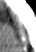


ID_095c522a_ID_19cfefdccb_s012_inst1  Reader1(pred)=SDH  GT=SDH  VLM=NONE



ID_095c522a_ID_19cfefdccb_s018_inst1  Reader1(pred)=SDH  GT=SDH  VLM=NONE


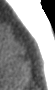


ID_095c522a_ID_19cfefdccb_s019_inst1  Reader1(pred)=SDH  GT=SDH  VLM=NONE



ID_0a040036_ID_44cc017f8a_s013_inst2  Reader1(pred)=IPH  GT=NONE  VLM=IPH



ID_0a040036_ID_44cc017f8a_s013_inst3  Reader1(pred)=IVH  GT=NONE  VLM=IPH



ID_0a040036_ID_44cc017f8a_s014_inst1  Reader1(pred)=IPH  GT=IPH  VLM=SDH


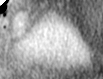


ID_0bee00a2_ID_0b9e78b135_s010_inst1  Reader1(pred)=IVH  GT=IPH  VLM=NONE


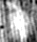


ID_0bee00a2_ID_0b9e78b135_s011_inst1  Reader1(pred)=IPH  GT=IVH  VLM=NONE


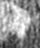


ID_0bee00a2_ID_0b9e78b135_s012_inst2  Reader1(pred)=IVH  GT=IVH  VLM=IPH


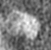


ID_0bee00a2_ID_0b9e78b135_s012_inst3  Reader1(pred)=IVH  GT=IVH  VLM=IPH



ID_0bee00a2_ID_0b9e78b135_s013_inst2  Reader1(pred)=IVH  GT=IVH  VLM=IPH


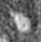


ID_0bee00a2_ID_0b9e78b135_s013_inst3  Reader1(pred)=IVH  GT=IVH  VLM=NONE



ID_0bee00a2_ID_0b9e78b135_s014_inst1  Reader1(pred)=IVH  GT=IVH  VLM=IPH


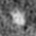


ID_0bee00a2_ID_0b9e78b135_s015_inst1  Reader1(pred)=IVH  GT=IVH  VLM=IPH



ID_0bee00a2_ID_0b9e78b135_s015_inst2  Reader1(pred)=IVH  GT=IVH  VLM=NONE


In [37]:
# 오답 확인 (2cls의 show_vlm_errors 패턴, GT/pred 둘 다 표시)
def show_vlm_errors(pred_records, max_display=None):
    df = pd.DataFrame(with_ground_truth(pred_records))

    gt_label = np.where(df["gt_is_lesion"], df["gt_class_name"], "NONE")
    vlm_label = np.where(df["vlm_is_lesion"], df["vlm_lesion_type"], "NONE")
    is_wrong = gt_label != vlm_label
    errors = df[is_wrong].copy()
    errors["gt_label"] = gt_label[is_wrong]
    errors["vlm_label"] = vlm_label[is_wrong]

    print(f"오답(vs GT) {len(errors)}개 / 전체 {len(df)}개")

    shown = errors if max_display is None else errors.head(max_display)
    for _, r in shown.iterrows():
        print(f"\n{r['id']}  Reader1(pred)={r['pred_class_name']}  GT={r['gt_label']}  VLM={r['vlm_label']}")
        display(Image.open(r["images"]["cropped"]))

    return errors


errors = show_vlm_errors(results_to_eval, max_display=20)

In [38]:
errors_df = show_vlm_errors(results_to_eval, max_display=0)  # max_display=0 → 이미지 출력 없이 df만

out_csv = EXP_OUT_DIR / "output" / "vlm_errors.csv"
save_df = errors_df.copy()
save_df["overlay_path"] = save_df["images"].map(lambda d: d["overlay"])
save_df["crop_path"] = save_df["images"].map(lambda d: d["cropped"])
save_df = save_df.drop(columns=["images"])
save_df.to_csv(out_csv, index=False)
print(f"저장: {out_csv} ({len(save_df)}개)")

오답(vs GT) 577개 / 전체 984개
저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-5cls/output/vlm_errors.csv (577개)


In [39]:
import SimpleITK as sitk
from skimage.measure import label as sklabel, regionprops

PRED_5CLS_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_predictions/Dataset001_MBHSeg25/2d_pp/MBH-Seg25")
GT_5CLS_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/test_data/Test1_MBHSeg25/labelsTs")

def load_lps_array(path):
    img_sitk = sitk.ReadImage(str(path))
    img_lps = sitk.DICOMOrient(img_sitk, "LPS")
    return sitk.GetArrayFromImage(img_lps)


def correct_case_volume_5cls(case_id, records_for_case):
    """VLM 판정을 실제 5cls 예측 볼륨에 반영 — is_lesion=False면 제거, 아니면 vlm_lesion_type
    클래스로 재라벨링. dataset 만들 때 쓴 것과 동일하게 클래스별 connected component로
    인스턴스를 다시 뽑아 bbox로 픽셀을 특정한다."""
    name_to_class = {v: k for k, v in class_names.items()}
    pred = load_lps_array(PRED_5CLS_DIR / f"{case_id}.nii.gz").astype(np.uint8)
    corrected = pred.copy()

    by_slice = {}
    for r in records_for_case:
        by_slice.setdefault(r["slice_idx"], []).append(r)

    for z, recs in by_slice.items():
        slice_pred = pred[z]
        bbox_to_mask = {}
        for cls_id in np.unique(slice_pred):
            if cls_id == 0:
                continue
            labeled = sklabel(slice_pred == cls_id)
            for region in regionprops(labeled):
                bbox_to_mask[tuple(region.bbox)] = (labeled == region.label)

        for r in recs:
            inst_mask = bbox_to_mask.get(tuple(r["bbox"]))
            if inst_mask is None:
                print(f"[경고] bbox 매칭 실패: {r['id']}")
                continue
            if not r["vlm_is_lesion"]:
                corrected[z][inst_mask] = 0
            else:
                corrected[z][inst_mask] = name_to_class[r["vlm_lesion_type"]]

    return corrected

def evaluate_dice_nnunet_style(pred_paths, gt_dir, classes=(1, 2, 3, 4, 5)):
    """nnUNet summary.json과 동일한 방식.
    1) 케이스 x 클래스마다 Dice (둘 다 없으면 NaN)
    2) 클래스별로 케이스 평균(nanmean)
    3) 클래스 5개 평균(가중치 없는 단순 평균) = foreground_mean
    """
    per_case_class = {c: [] for c in classes}
    for case_id, pred_path in pred_paths.items():
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        pred = load_lps_array(pred_path).astype(np.uint8)
        for c in classes:
            p, g = pred == c, gt == c
            if p.sum() == 0 and g.sum() == 0:
                per_case_class[c].append(np.nan)
                continue
            inter = np.logical_and(p, g).sum()
            per_case_class[c].append(2 * inter / (p.sum() + g.sum()))

    class_mean = {class_names[c]: float(np.nanmean(per_case_class[c])) for c in classes}
    foreground_mean = float(np.mean(list(class_mean.values())))
    return class_mean, foreground_mean

    
# baseline_paths — 원본(보정 전) nnUNet 예측 경로, VLM으로 평가한 41케이스 기준
eval_case_ids = sorted({r["case_id"] for r in results_to_eval})
baseline_paths = {cid: PRED_5CLS_DIR / f"{cid}.nii.gz" for cid in eval_case_ids}

# by_case — VLM 예측 레코드(GT join 포함)를 case_id별로 묶은 딕셔너리
by_case = {}
for r in with_ground_truth(results_to_eval):
    by_case.setdefault(r["case_id"], []).append(r)

# evaluate_dice_nnunet_style_arrays — 이미 메모리에 올라온 pred 볼륨(np.ndarray)을 받아
# nnUNet summary.json과 동일한 방식(케이스x클래스 Dice → 클래스별 nanmean → 5클래스 단순평균)으로 계산
def evaluate_dice_nnunet_style_arrays(pred_arrays, gt_dir, classes=(1, 2, 3, 4, 5)):
    per_case_class = {c: [] for c in classes}
    for case_id, pred in pred_arrays.items():
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        for c in classes:
            p, g = pred == c, gt == c
            if p.sum() == 0 and g.sum() == 0:
                per_case_class[c].append(np.nan)
                continue
            inter = np.logical_and(p, g).sum()
            per_case_class[c].append(2 * inter / (p.sum() + g.sum()))
    class_mean = {class_names[c]: float(np.nanmean(per_case_class[c])) for c in classes}
    return class_mean, float(np.mean(list(class_mean.values())))


# 1) 검증: summary.json 재현 (전체 48케이스로, eval_case_ids 41개 말고 PRED_5CLS_DIR 전체)
all_pred_paths = {p.stem.replace(".nii", ""): p for p in PRED_5CLS_DIR.glob("*.nii.gz")}
check_class_mean, check_fg_mean = evaluate_dice_nnunet_style(all_pred_paths, GT_5CLS_DIR)
print("재현 결과:", {k: round(v, 4) for k, v in check_class_mean.items()})
print(f"foreground mean: {check_fg_mean:.4f}  (summary.json: 0.3803)")

# 2) 원본(41케이스, VLM 평가 대상만) — baseline
baseline_class_mean, baseline_fg_mean = evaluate_dice_nnunet_style(baseline_paths, GT_5CLS_DIR)
print("\n원본(41케이스):", {k: round(v, 4) for k, v in baseline_class_mean.items()})
print(f"원본 foreground mean: {baseline_fg_mean:.4f}")

# 3) VLM 보정 후 — 같은 방식으로
corrected_cache = {case_id: correct_case_volume_5cls(case_id, recs) for case_id, recs in by_case.items()}

corrected_class_mean, corrected_fg_mean = evaluate_dice_nnunet_style_arrays(corrected_cache, GT_5CLS_DIR)
print("VLM 보정 후(41케이스):", {k: round(v, 4) for k, v in corrected_class_mean.items()})
print(f"VLM 보정 후 foreground mean: {corrected_fg_mean:.4f}")

corrected_paths_getter = {cid: corrected_cache[cid] for cid in corrected_cache}  # 이전 셀의 corrected_cache 재사용
def evaluate_dice_nnunet_style_arrays(pred_arrays, gt_dir, classes=(1, 2, 3, 4, 5)):
    per_case_class = {c: [] for c in classes}
    for case_id, pred in pred_arrays.items():
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        for c in classes:
            p, g = pred == c, gt == c
            if p.sum() == 0 and g.sum() == 0:
                per_case_class[c].append(np.nan)
                continue
            inter = np.logical_and(p, g).sum()
            per_case_class[c].append(2 * inter / (p.sum() + g.sum()))
    class_mean = {class_names[c]: float(np.nanmean(per_case_class[c])) for c in classes}
    return class_mean, float(np.mean(list(class_mean.values())))

corrected_class_mean, corrected_fg_mean = evaluate_dice_nnunet_style_arrays(corrected_cache, GT_5CLS_DIR)
print("\nVLM 보정 후(41케이스):", {k: round(v, 4) for k, v in corrected_class_mean.items()})
print(f"VLM 보정 후 foreground mean: {corrected_fg_mean:.4f}")


재현 결과: {'EDH': 0.1724, 'IPH': 0.6115, 'IVH': 0.4945, 'SAH': 0.3236, 'SDH': 0.2993}
foreground mean: 0.3803  (summary.json: 0.3803)

원본(41케이스): {'EDH': 0.1724, 'IPH': 0.6115, 'IVH': 0.4945, 'SAH': 0.3236, 'SDH': 0.3135}
원본 foreground mean: 0.3831
VLM 보정 후(41케이스): {'EDH': 0.0289, 'IPH': 0.3007, 'IVH': 0.1454, 'SAH': 0.1559, 'SDH': 0.1851}
VLM 보정 후 foreground mean: 0.1632

VLM 보정 후(41케이스): {'EDH': 0.0289, 'IPH': 0.3007, 'IVH': 0.1454, 'SAH': 0.1559, 'SDH': 0.1851}
VLM 보정 후 foreground mean: 0.1632


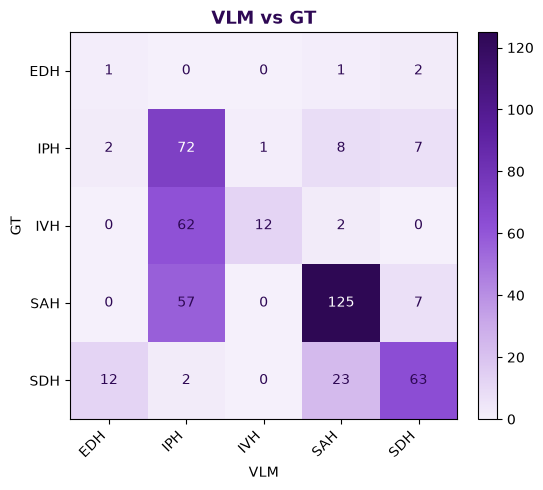

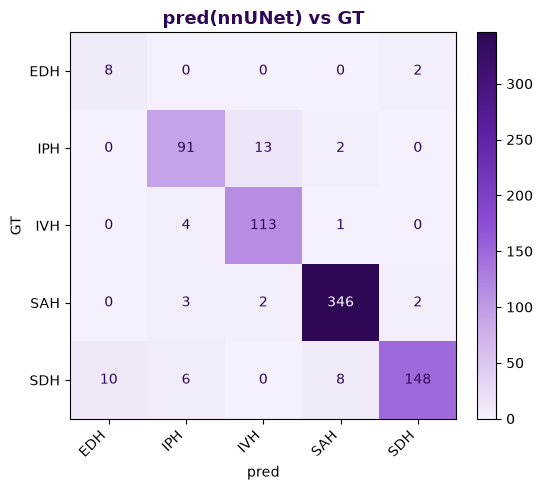

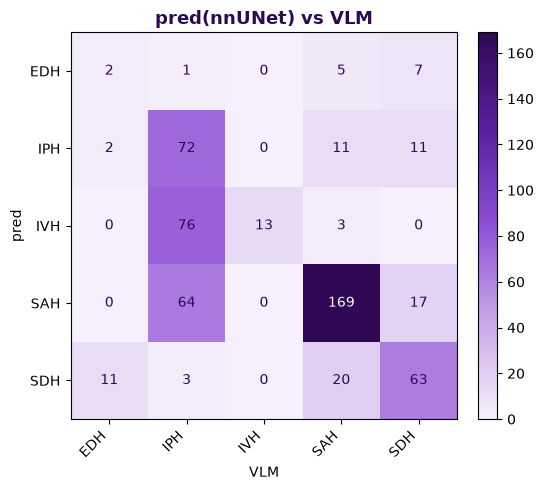

In [40]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

PURPLE_CMAP = LinearSegmentedColormap.from_list(
    "purple_theme", ["#f5f0fb", "#c9a8e9", "#8e4fd6", "#5b1f9e", "#2e0854"]
)

def plot_confusion(confusion_df, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(confusion_df.values, cmap=PURPLE_CMAP)

    ax.set_xticks(range(len(confusion_df.columns)))
    ax.set_xticklabels(confusion_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(confusion_df.index)))
    ax.set_yticklabels(confusion_df.index)
    ax.set_xlabel(confusion_df.columns.name or "")
    ax.set_ylabel(confusion_df.index.name or "")
    ax.set_title(title, fontsize=13, fontweight="bold", color="#2e0854")

    vmax = confusion_df.values.max()
    for i in range(confusion_df.shape[0]):
        for j in range(confusion_df.shape[1]):
            val = confusion_df.values[i, j]
            color = "white" if val > vmax * 0.55 else "#2e0854"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


#  VLM vs GT
tp = vlm_eval_df[vlm_eval_df["gt_is_lesion"] & vlm_eval_df["vlm_is_lesion"]]
confusion = pd.crosstab(tp["gt_class_name"], tp["vlm_lesion_type"], rownames=["GT"], colnames=["VLM"])
plot_confusion(confusion, "VLM vs GT")

#  pred vs GT
tp2 = vlm_eval_df[vlm_eval_df["gt_is_lesion"] & vlm_eval_df["pred_is_lesion"]]
confusion2 = pd.crosstab(tp2["gt_class_name"], tp2["pred_class_name"], rownames=["GT"], colnames=["pred"])
plot_confusion(confusion2, "pred(nnUNet) vs GT")

# VLM vs pred
tp3 = vlm_eval_df[vlm_eval_df["pred_is_lesion"] & vlm_eval_df["vlm_is_lesion"]]
confusion3 = pd.crosstab(tp3["pred_class_name"], tp3["vlm_lesion_type"], rownames=["pred"], colnames=["VLM"])
plot_confusion(confusion3, "pred(nnUNet) vs VLM")


In [41]:
def find_missed_gt_instances(case_ids, gt_dir, pred_dir, class_names, min_pixels=5):
    """GT 병변 connected component 중, 같은 자리에 pred(Reader#1) 픽셀이 전혀 없는(완전히 놓친)
    것만 찾는다. 지금까지의 confusion matrix는 전부 'pred가 만든 connected component'에서
    출발해서, 이런 완전 누락(진짜 false negative)은 애초에 인스턴스로 존재한 적이 없어 반영되지 않았다."""
    missed = []
    for case_id in case_ids:
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        pred = load_lps_array(pred_dir / f"{case_id}.nii.gz").astype(np.uint8)
        for z in range(gt.shape[0]):
            gt_slice = gt[z]
            if not np.any(gt_slice > 0):
                continue
            pred_slice = pred[z]
            for cls_id, cls_name in class_names.items():
                if cls_id == 0:
                    continue
                labeled = sklabel(gt_slice == cls_id)
                for region in regionprops(labeled):
                    inst_mask = labeled == region.label
                    if inst_mask.sum() < min_pixels:
                        continue
                    if not np.any(pred_slice[inst_mask] > 0):
                        missed.append({
                            "case_id": case_id, "slice_idx": z,
                            "gt_class_name": cls_name, "pixel_count": int(inst_mask.sum()),
                        })
    return missed


missed_instances = find_missed_gt_instances(eval_case_ids, GT_5CLS_DIR, PRED_5CLS_DIR, class_names)
print(f"Reader#1이 완전히 놓친(같은 자리에 pred 픽셀이 전혀 없는) GT 병변 인스턴스: {len(missed_instances)}개")

# 1) 기존 'pred vs GT' 5x5 confusion(=agree 서브셋)에 놓친 것까지 NONE(놓침) 열로 추가
tp2 = vlm_eval_df[vlm_eval_df["gt_is_lesion"] & vlm_eval_df["pred_is_lesion"]]
full_confusion = pd.crosstab(tp2["gt_class_name"], tp2["pred_class_name"], rownames=["GT"], colnames=["pred"])
full_confusion["NONE(놓침)"] = 0
for m in missed_instances:
    full_confusion.loc[m["gt_class_name"], "NONE(놓침)"] += 1

# 2) 배경을 병변으로 오검출한 FP까지 NONE(FP) 행으로 추가
class_cols = [c for c in full_confusion.columns if c != "NONE(놓침)"]
fp_counts = vlm_eval_df[~vlm_eval_df["gt_is_lesion"]]["pred_class_name"].value_counts()
# GT=배경, pred=배경은 전체 배경 픽셀 전체라 "인스턴스" 개념이 없어 정의 불가 → NaN
full_confusion.loc["NONE(FP)"] = [fp_counts.get(c, 0) for c in class_cols] + [np.nan]

print("\n=== pred vs GT confusion matrix (배경/완전 누락 포함) ===")
display(full_confusion)

print("\n=== 놓침까지 포함한 클래스별 진짜 recall ===")
for cls in class_names.values():
    if cls == "NONE" or cls not in full_confusion.index:
        continue
    row = full_confusion.loc[cls, class_cols + ["NONE(놓침)"]]
    total = row.sum()
    correct = row[cls] if cls in row.index else 0
    print(f"  {cls}: {correct}/{total} = {correct/total:.4f}")

Reader#1이 완전히 놓친(같은 자리에 pred 픽셀이 전혀 없는) GT 병변 인스턴스: 399개

=== pred vs GT confusion matrix (배경/완전 누락 포함) ===


pred,EDH,IPH,IVH,SAH,SDH,NONE(놓침)
GT,,,,,,
EDH,8.0,0.0,0.0,0.0,2.0,6.0
IPH,0.0,91.0,13.0,2.0,0.0,25.0
IVH,0.0,4.0,113.0,1.0,0.0,27.0
SAH,0.0,3.0,2.0,346.0,2.0,170.0
SDH,10.0,6.0,0.0,8.0,148.0,171.0
NONE(FP),12.0,13.0,26.0,134.0,40.0,NaN



=== 놓침까지 포함한 클래스별 진짜 recall ===
  EDH: 8.0/16.0 = 0.5000
  IPH: 91.0/131.0 = 0.6947
  IVH: 113.0/145.0 = 0.7793
  SAH: 346.0/523.0 = 0.6616
  SDH: 148.0/343.0 = 0.4315


In [44]:
IMAGES_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/test_data/Test1_MBHSeg25/imagesTs")

from matplotlib.colors import ListedColormap

def build_cmap(color_dict, n_classes):
    colors_rgb = np.zeros((n_classes, 3))
    for cls, rgb in color_dict.items():
        colors_rgb[cls] = np.array(rgb) / 255.0
    return ListedColormap(colors_rgb)

cmap_5cls = build_cmap(class_colors, 6)  # 0(background)~5

all_case_ids = eval_case_ids  # cell 18에서 만든 41케이스 리스트 재사용


def show_case(case_idx, slice_idx=None):
    """case_idx: eval_case_ids(=all_case_ids)에서의 순번.
    slice_idx를 주면 그 슬라이스, 안 주면 5cls GT 전경이 가장 많은 슬라이스를 자동 선택.
    패널 순서: GT(mask) / Pred 5cls(nnUNet, mask+bbox) / VLM classifier(mask+bbox).
    Pred/VLM 패널의 bbox는 GT 기준으로 맞으면 초록, 틀리면 빨강."""
    case_id = all_case_ids[case_idx]
    img = load_lps_array(IMAGES_DIR / f"{case_id}_0000.nii.gz")
    gt_5cls = load_lps_array(GT_5CLS_DIR / f"{case_id}.nii.gz").astype(np.uint8)
    pred = load_lps_array(PRED_5CLS_DIR / f"{case_id}.nii.gz").astype(np.uint8)

    if slice_idx is None:
        fg_per_slice = (gt_5cls > 0).sum(axis=(1, 2))
        slice_idx = int(fg_per_slice.argmax())

    windowed = apply_window(img[slice_idx])
    gt_slice = gt_5cls[slice_idx]
    pred_slice = pred[slice_idx]

    slice_recs = [r for r in results_to_eval if r["case_id"] == case_id and r["slice_idx"] == slice_idx]
    joined = with_ground_truth(slice_recs)

    # nnUNet 5cls pred -> VLM classifier 판정으로 재라벨링. 클래스별로 connected component를
    # 따로 뽑아 bbox 매칭한다 (correct_case_volume_5cls와 동일 방식) — 서로 다른 클래스 인스턴스가
    # 붙어있어도 한 덩어리로 섞이지 않게.
    name_to_class = {v: k for k, v in class_names.items()}
    bbox_to_mask = {}
    for cls_id in np.unique(pred_slice):
        if cls_id == 0:
            continue
        labeled = sklabel(pred_slice == cls_id)
        for region in regionprops(labeled):
            bbox_to_mask[tuple(region.bbox)] = (labeled == region.label)

    vlm_mask = np.zeros_like(pred_slice)
    for r in joined:
        inst_mask = bbox_to_mask.get(tuple(r["bbox"]))
        if inst_mask is None or not r["vlm_is_lesion"]:
            continue
        vlm_mask[inst_mask] = name_to_class.get(r["vlm_lesion_type"], 0)

    gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
    pred_overlay = np.ma.masked_where(pred_slice == 0, pred_slice)
    vlm_overlay = np.ma.masked_where(vlm_mask == 0, vlm_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[0].imshow(gt_overlay, cmap=cmap_5cls, vmin=0, vmax=5, alpha=0.6)
    axes[0].set_title(f"{case_id} (z={slice_idx}/{img.shape[0]-1}) — GT mask (5cls)")
    axes[0].axis("off")

    axes[1].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(pred_overlay, cmap=cmap_5cls, vmin=0, vmax=5, alpha=0.6)
    axes[1].set_title("Pred 5cls (nnUNet)")
    axes[1].axis("off")

    axes[2].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(vlm_overlay, cmap=cmap_5cls, vmin=0, vmax=5, alpha=0.6)
    axes[2].set_title("Pred 5cls → VLM classifier")
    axes[2].axis("off")

    for r in joined:
        y0, x0, y1, x1 = r["bbox"]
        gt_lbl = r["gt_class_name"] if r["gt_is_lesion"] else "NONE"

        # Pred(Reader#1) 패널 — Reader#1은 항상 자기 candidate를 병변이라 주장하므로 pred_class_name 그대로 비교
        pred_lbl = r["pred_class_name"]
        pred_correct = pred_lbl == gt_lbl
        pred_color = "lime" if pred_correct else "red"
        axes[1].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=pred_color, linewidth=1.5))

        # VLM 패널
        vlm_lbl = r["vlm_lesion_type"] if r["vlm_is_lesion"] else "NONE"
        vlm_correct = vlm_lbl == gt_lbl
        vlm_color = "lime" if vlm_correct else "red"
        axes[2].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=vlm_color, linewidth=1.5))

    plt.tight_layout()
    plt.show()

    print(f"case: {case_id} | z: {slice_idx}")
    for r in joined:
        gt_lbl = r["gt_class_name"] if r["gt_is_lesion"] else "NONE"
        vlm_lbl = r["vlm_lesion_type"] if r["vlm_is_lesion"] else "NONE"
        print(f"  GT={gt_lbl} | Reader1(pred)={r['pred_class_name']} | VLM={vlm_lbl}")

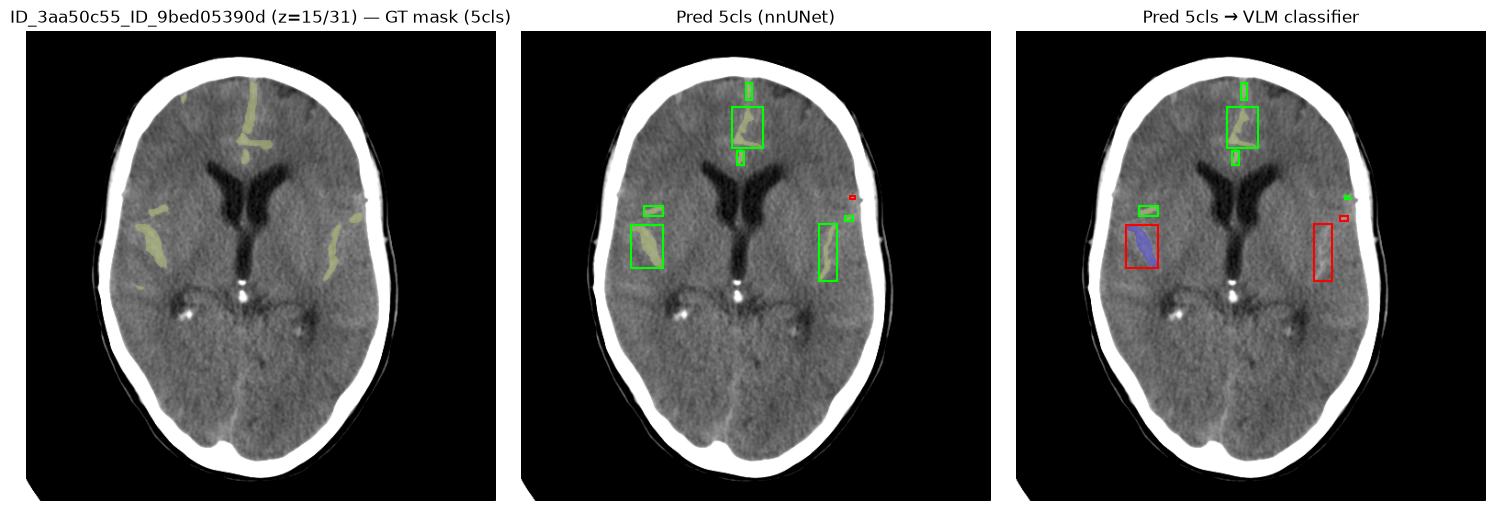

case: ID_3aa50c55_ID_9bed05390d | z: 15
  GT=SAH | Reader1(pred)=SAH | VLM=SAH
  GT=SAH | Reader1(pred)=SAH | VLM=SAH
  GT=SAH | Reader1(pred)=SAH | VLM=SAH
  GT=NONE | Reader1(pred)=SAH | VLM=NONE
  GT=SAH | Reader1(pred)=SAH | VLM=SAH
  GT=SAH | Reader1(pred)=SAH | VLM=NONE
  GT=SAH | Reader1(pred)=SAH | VLM=NONE
  GT=SAH | Reader1(pred)=SAH | VLM=IPH


In [63]:
show_case(case_idx=25, slice_idx=15)